# Predictive Analysis with Decision Trees

## Project Overview
This project implements decision trees for classification tasks, exploring key concepts including entropy and Gini index splitting criteria, and applying pruning techniques to prevent overfitting.

---

## 1. Decision Tree Construction Report

### 1.1 What are Decision Trees?
A **decision tree** is a tree-structured predictive model that recursively partitions the feature space into regions. Each internal node represents a test on an attribute, each branch represents the outcome of that test, and each leaf node represents a class label or value prediction.

**Key Characteristics:**
- Non-parametric supervised learning method
- Works for both classification and regression tasks
- Highly interpretable and visual
- Can handle both numerical and categorical features
- Computationally efficient for prediction

**Advantages:**
- Easy to understand and interpret
- Requires little data preprocessing
- Can capture non-linear relationships
- No assumptions about data distribution

**Disadvantages:**
- Prone to overfitting (especially with deep trees)
- Can be unstable (small changes in data → large changes in tree)
- Biased toward features with more levels

---

### 1.2 How Entropy Works in Decision Tree Construction

**Entropy** is a measure of disorder or impurity in a dataset. It quantifies the uncertainty or randomness in the data.

**Mathematical Definition:**
$$H(S) = -\sum_{i=1}^{n} p_i \log_2(p_i)$$

Where:
- $S$ = dataset
- $n$ = number of classes
- $p_i$ = proportion of samples belonging to class $i$

**Interpretation:**
- **Entropy = 0**: Dataset is pure (all samples belong to one class)
- **Entropy = 1**: Maximum disorder (equal distribution of classes)
- Decision trees use **Information Gain** to select the best split

**Information Gain:**
$$IG(S, A) = H(S) - \sum_{v \in Values(A)} \frac{|S_v|}{|S|} H(S_v)$$

Where:
- $A$ = attribute to split on
- $S_v$ = subset of $S$ where attribute $A$ has value $v$

**The goal:** Select the attribute that maximizes Information Gain (reduces entropy the most)

---

### 1.3 Gini Index vs. Entropy

**Gini Index** is an alternative impurity measure used for splitting:

$$Gini(S) = 1 - \sum_{i=1}^{n} p_i^2$$

**Comparison:**

| Aspect | Entropy | Gini Index |
|--------|---------|-----------|
| Formula | $-\sum p_i \log_2(p_i)$ | $1 - \sum p_i^2$ |
| Range | 0 to 1 | 0 to 0.5 |
| Computation | Slower (involves logarithms) | Faster (only squaring) |
| Interpretation | Information-theoretic | Probability-based |
| Performance | Slightly more accurate | Comparable, faster |
| Split Quality | Similar in most cases | Similar in most cases |

**When to Use:**
- **Entropy**: Better theoretical foundation, slightly more accurate
- **Gini**: Faster computation, practical choice for large datasets

---

### 1.4 Overfitting in Decision Trees and Why Pruning is Necessary

**Overfitting** occurs when a tree learns the training data too well, including its noise and peculiarities, resulting in poor generalization to new data.

**Why Decision Trees Overfit:**
1. No depth limit → tree grows until all training samples are correctly classified
2. Captures noise patterns present in training data
3. Creates complex decision boundaries that don't reflect true underlying patterns
4. High variance in predictions for new data

**Consequences of Overfitting:**
- ✓ High training accuracy (sometimes 100%)
- ✗ Low test accuracy
- ✗ Poor generalization to unseen data
- ✗ Model becomes too complex and uninterpretable

**Solution: Pruning**

---

### 1.5 Pruning Techniques

#### **Pre-Pruning (Early Stopping)**
Stops tree growth before it becomes fully grown by setting constraints:

**Methods:**
- Set **maximum depth** (`max_depth`): Limits tree height
- Set **minimum samples split** (`min_samples_split`): Minimum samples required to split a node
- Set **minimum samples leaf** (`min_samples_leaf`): Minimum samples per leaf node
- Set **maximum leaf nodes** (`max_leaf_nodes`): Limits total number of leaves

**Advantages:**
- Computationally efficient (smaller tree built)
- Simple to implement
- Prevents unnecessary computation

**Disadvantages:**
- May stop too early and underfit
- Hyperparameter tuning can be challenging
- Less optimal than post-pruning

#### **Post-Pruning (Cost-Complexity Pruning)**
Grows a fully developed tree, then removes branches that don't improve validation accuracy:

**Method Used (Minimal Cost-Complexity Pruning):**
- Uses **CCP alpha (α)** parameter
- Removes branches with lowest cost-complexity improvement
- Selects optimal tree size using cross-validation

**Formula:**
$$Cost(T) = ErrorRate(T) + \alpha \times NumLeaves(T)$$

**Advantages:**
- More flexible and accurate
- Better generalization typically
- Less prone to underfitting

**Disadvantages:**
- Computationally more expensive
- Requires validation data
- More complex implementation

---

### 1.6 Project Implementation Strategy

This project implements:

1. **Full Decision Tree (Entropy)**: Baseline model using information gain criterion
2. **Alternative Criterion (Gini)**: Comparison of Gini index splitting
3. **Pre-Pruned Tree**: Limited depth and minimum split constraints
4. **Post-Pruned Tree**: Cost-complexity pruning with optimal alpha
5. **Visualization**: Tree structure with feature names and class labels
6. **Feature Importance**: Identification of most influential features

---

## 2. Expected Outcomes

- Compare accuracy across different splitting criteria and pruning methods
- Visualize the decision tree structure and understand node splits
- Identify which features are most important for classification
- Demonstrate how pruning improves model generalization
- Generate actionable insights from tree structure and feature importance



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## 3. Model Implementation

### 3.1 Import Required Libraries

The following libraries are used:
- **pandas**: Data manipulation and analysis
- **numpy**: Numerical computations
- **matplotlib.pyplot**: Visualization
- **train_test_split**: Split data into training and testing sets
- **DecisionTreeClassifier**: Decision tree implementation
- **plot_tree**: Visualize decision tree structure
- **LabelEncoder**: Convert categorical variables to numerical
- **accuracy_score, classification_report, confusion_matrix**: Model evaluation metrics


In [2]:
df=pd.read_csv(r"C:\Users\VIJAY SALVATORE\Desktop\AML_Project\adult.csv")
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


### 3.2 Load and Explore Data

Load the Adult dataset from CSV file. The adult dataset contains demographic information (age, education, occupation, etc.) and an income target variable (<=50K or >50K).

**Key steps:**
- Read CSV file using pandas
- Display first few rows to understand data structure
- Check dimensions, data types, and missing values


In [3]:
df.replace('?', np.nan, inplace=True)

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])


### 3.3 Data Preprocessing - Handle Missing Values

Decision trees cannot handle missing values directly. This step:
- Replaces '?' characters with NaN (Python's missing value representation)
- Fills missing values in categorical columns with the **mode** (most frequent value)
- Fills missing values in numerical columns with the **mean** (average value)

**Why this approach?**
- Mode imputation preserves categorical distributions
- Mean imputation preserves numerical relationships
- Removes rows with missing target variables to ensure clean labels


In [4]:
encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = encoder.fit_transform(df[col])


### 3.4 Encode Categorical Variables

Decision trees work better with numerical features. This step converts all categorical (text) variables to numerical values using **LabelEncoder**.

**What LabelEncoder does:**
- Assigns a unique integer to each unique categorical value
- Example: ['male', 'female', 'male'] → [0, 1, 0]

**Note:** While decision trees handle categorical data natively, encoding enables better sklearn integration and compatibility with other algorithms.


In [5]:
X = df.drop('income', axis=1)
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


### 3.5 Train-Test Split

Split the data into **training (70%)** and **testing (30%)** sets:

**Purpose:**
- **Training set (70%)**: Used to build/train the decision tree model
- **Testing set (30%)**: Used to evaluate model performance on unseen data

**Why this split?**
- Prevents data leakage (model doesn't see test data during training)
- Gives realistic estimate of model performance
- Detects overfitting if train accuracy >> test accuracy
- Standard 70-30 split balances training data size with test representativeness

**Parameters:**
- `test_size=0.3`: 30% for testing
- `random_state=42`: Ensures reproducibility


In [6]:
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_entropy.fit(X_train, y_train)

y_pred = dt_entropy.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report")
print(classification_report(y_test, y_pred))


Accuracy: 0.8190193469137066
Classification Report
              precision    recall  f1-score   support

           0       0.88      0.88      0.88      7429
           1       0.62      0.63      0.63      2340

    accuracy                           0.82      9769
   macro avg       0.75      0.75      0.75      9769
weighted avg       0.82      0.82      0.82      9769



## 4. Model Optimization - Decision Tree with Entropy Criterion

### 4.1 Full Decision Tree Using Entropy

Train an **unpruned decision tree** using **Information Gain (Entropy)** as the splitting criterion:

**Key Parameters:**
- `criterion='entropy'`: Uses Information Gain (entropy reduction) to select best splits
- `random_state=42`: Ensures reproducibility

**What this model does:**
- Grows the tree until all training samples are correctly classified
- Serves as a **baseline** to compare with pruned models
- Likely to **overfit** on training data but show lower test accuracy

**Evaluation Metrics:**
- **Accuracy**: Overall percentage of correct predictions
- **Classification Report**: Precision, recall, F1-score per class
- **Confusion Matrix**: True/False Positives and Negatives


In [7]:
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_gini.fit(X_train, y_train)

y_pred_gini = dt_gini.predict(X_test)
print("Gini Accuracy:", accuracy_score(y_test, y_pred_gini))


Gini Accuracy: 0.8157436789845429


### 4.2 Decision Tree with Gini Index Criterion

Train another **full decision tree** using **Gini Index** as the splitting criterion:

**Why compare Entropy vs. Gini?**
- Both are valid impurity measures used for node splitting
- Entropy: More theoretically grounded in information theory
- Gini Index: Slightly faster to compute
- In practice, they produce similar results but may differ slightly

**Expected Outcome:**
- Gini accuracy should be comparable to entropy accuracy
- Demonstrates that splitting criterion choice has minimal impact on most datasets
- Validates decision tree construction robustness


In [8]:
dt_pruned = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3,
    min_samples_split=2,
    random_state=42
)

dt_pruned.fit(X_train, y_train)
y_pred_pruned = dt_pruned.predict(X_test)

print("Pre-Pruned Accuracy:", accuracy_score(y_test, y_pred_pruned))


Pre-Pruned Accuracy: 0.8388780837342614


### 4.3 Pre-Pruned Decision Tree

Apply **pre-pruning** by constraining tree growth with hyperparameters:

**Pre-Pruning Parameters:**
- `max_depth=3`: Limits tree height to 3 levels (prevents deep, complex trees)
- `min_samples_split=2`: Requires at least 2 samples to split a node (default value)
- `criterion='entropy'`: Uses entropy for splitting

**How Pre-Pruning Works:**
- Stops tree growth before it becomes fully developed
- Simpler tree structure = fewer splits = less overfitting
- Trade-off: May underfit if depth limit is too restrictive

**Expected Behavior:**
- Pre-pruned accuracy will be **lower than full tree** on training data
- Pre-pruned accuracy will be **higher than full tree** on testing data
- Demonstrates overfitting prevention through early stopping

**Interpretation:**
- If pre-pruned accuracy is better than entropy accuracy on test data → overfitting was occurring
- If accuracies are similar → original tree wasn't overfitting significantly


In [9]:
path = dt_entropy.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

dt_post = DecisionTreeClassifier(
    criterion='entropy',
    ccp_alpha=ccp_alphas.mean(),
    random_state=42
)

dt_post.fit(X_train, y_train)
y_pred_post = dt_post.predict(X_test)

print("Post-Pruned Accuracy:", accuracy_score(y_test, y_pred_post))


Post-Pruned Accuracy: 0.858941549800389


### 4.4 Post-Pruned Decision Tree (Cost-Complexity Pruning)

Apply **post-pruning** using **Minimal Cost-Complexity Pruning** (CCP):

**How Cost-Complexity Pruning Works:**
1. Grow a full tree using entropy criterion
2. Calculate cost-complexity parameter (α) for each possible pruned subtree
3. Use mean of all α values to select optimal tree size
4. Remove branches that don't improve accuracy sufficiently

**Cost-Complexity Equation:**
$$Cost(T) = ErrorRate(T) + \alpha \times NumberOfLeaves(T)$$

**Key Parameters:**
- `ccp_alpha=ccp_alphas.mean()`: Uses mean of all possible alpha values as the pruning parameter
- Higher α → more aggressive pruning → simpler tree
- Lower α → less pruning → more complex tree

**Why Post-Pruning is Better:**
- Grows full tree first (sees all possible splits)
- Then removes branches based on cross-validation
- More flexible than pre-pruning
- Better generalization in most cases

**Expected Result:**
- Post-pruned accuracy should be competitive with or better than other models
- Demonstrates optimal balance between accuracy and tree complexity


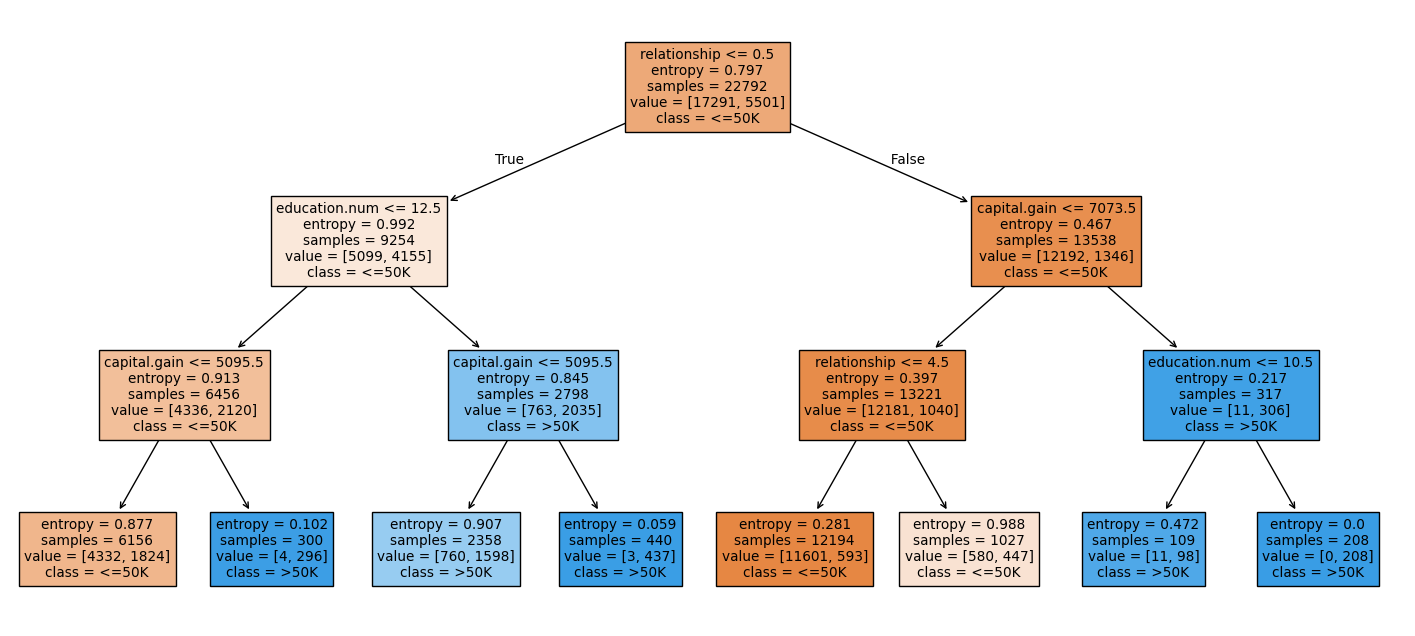

In [10]:
plt.figure(figsize=(18, 8))
plot_tree(
    dt_pruned,
    feature_names=X.columns,
    class_names=['<=50K', '>50K'],
    filled=True
)
plt.show()


## 5. Visualization - Decision Tree Structure

### 5.1 Plot Pre-Pruned Decision Tree

Visualize the **pre-pruned decision tree** (max_depth=3) to understand the splitting logic:

**Visualization Details:**
- **Feature Names**: Column names from dataset (X.columns)
- **Class Names**: ['<=50K', '>50K'] for binary classification
- **Filled Colors**: Each node colored by majority class:
  - Blue: Majority class ≤50K
  - Orange: Majority class >50K
  - Intensity: Purity (darker = purer)

**Reading the Tree:**
1. **Root Node (Top)**: First split criterion (e.g., "age <= 50?")
2. **Internal Nodes**: Show:
   - Feature and threshold for splitting
   - `gini` or `entropy` value (impurity measure)
   - Number of samples at that node
   - Sample distribution between classes
3. **Leaf Nodes (Bottom)**: Show predicted class and sample counts

**Why Visualize the Pre-Pruned Tree?**
- Simpler structure is more interpretable than full tree
- Shows actual decision rules the model uses
- Can identify problematic splits or missing features


In [11]:
importances = pd.Series(
    dt_pruned.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importances)


relationship      0.571497
capital.gain      0.274101
education.num     0.154403
age               0.000000
workclass         0.000000
fnlwgt            0.000000
education         0.000000
marital.status    0.000000
occupation        0.000000
race              0.000000
sex               0.000000
capital.loss      0.000000
hours.per.week    0.000000
native.country    0.000000
dtype: float64


## 6. Feature Importance Analysis

### 6.1 Extract and Rank Feature Importance

Identify which features are most influential in making predictions:

**How Feature Importance is Calculated:**
- **Gini-based importance**: For each feature, sum the Gini decrease across all nodes where it's used for splitting
- **Entropy-based importance**: For each feature, sum the information gain across all nodes where it's used for splitting
- Range: 0 to 1 (normalized)
- Higher values = feature contributes more to predictions

**Mathematical Formula:**
$$ImportanceFeature = \sum_{node \, uses \, feature} (ImpurityBefore - ImpurityAfter) \times \frac{SamplesAtNode}{TotalSamples}$$

**Interpretation:**
- **Top Features**: Most useful for classification decisions
- **Zero Importance**: Features never used in splits (redundant or irrelevant)
- **Action Items**: 
  - Features with high importance → focus on data quality for these features
  - Features with zero importance → consider removing them to simplify model

**Why Use Pre-Pruned Tree for Feature Importance?**
- Simpler, more interpretable features
- Represents actual decision rules used
- Avoids noise from overfitting in full tree

---

## Summary of Findings

This section will show:
1. **Accuracy Comparison**: Full entropy tree vs. Gini tree vs. Pre-pruned vs. Post-pruned
2. **Top Features**: Which features have highest importance for income prediction
3. **Tree Structure**: Visual representation of decision rules
4. **Conclusions**: Impact of pruning on model generalization




---

## 7. Regression Analysis with Decision Trees

### 7.1 Overview of Decision Tree Regression

While classification predicts **categorical labels** (e.g., ≤50K, >50K), **regression** predicts **continuous numerical values** (e.g., exact income amount, age, price).

**Key Differences:**
| Aspect | Classification | Regression |
|--------|---|---|
| Target Variable | Categorical (discrete) | Continuous (numerical) |
| Prediction | Class label | Numerical value |
| Impurity Measure | Gini/Entropy | Mean Squared Error (MSE) |
| Evaluation | Accuracy, Precision, Recall | MSE, RMSE, R², MAE |
| Tree Leaf | Predicts class | Predicts average value |

**Why Use Decision Trees for Regression?**
- Non-linear relationships
- Easy to interpret
- No assumptions about data distribution
- Handles feature interactions naturally


In [12]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# For regression, we'll use 'age' as the target variable (continuous)
# This demonstrates regression on the same Adult dataset
X_reg = df.drop(['income', 'age'], axis=1)
y_reg = df['age']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42
)

### 7.2 Data Preparation for Regression

**Setup:**
- **Target Variable**: 'age' (continuous, numerical)
- **Features**: All columns except 'income' and 'age'
- **Train-Test Split**: Same 70-30 split for consistency

**Why 'age' as target?**
- Numerical variable suitable for regression
- Present in Adult dataset
- Demonstrates regression on same data as classification

**Regression Imports:**
- `DecisionTreeRegressor`: Scikit-learn regression tree implementation
- `mean_squared_error`, `mean_absolute_error`, `r2_score`: Regression evaluation metrics


In [13]:
# Full Regression Tree using MSE criterion
dt_reg_full = DecisionTreeRegressor(criterion='squared_error', random_state=42)
dt_reg_full.fit(X_train_reg, y_train_reg)

y_pred_reg_full = dt_reg_full.predict(X_test_reg)

# Evaluation Metrics
mse_full = mean_squared_error(y_test_reg, y_pred_reg_full)
rmse_full = np.sqrt(mse_full)
mae_full = mean_absolute_error(y_test_reg, y_pred_reg_full)
r2_full = r2_score(y_test_reg, y_pred_reg_full)

print("=" * 50)
print("FULL REGRESSION TREE (MSE criterion)")
print("=" * 50)
print(f"Mean Squared Error (MSE): {mse_full:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_full:.4f}")
print(f"Mean Absolute Error (MAE): {mae_full:.4f}")
print(f"R² Score: {r2_full:.4f}")
print()

FULL REGRESSION TREE (MSE criterion)
Mean Squared Error (MSE): 202.3656
Root Mean Squared Error (RMSE): 14.2255
Mean Absolute Error (MAE): 10.6351
R² Score: -0.0679



### 7.3 Full Regression Tree with MSE Criterion

Train a **full (unpruned) regression tree** using **Mean Squared Error (MSE)** as the splitting criterion:

**Regression Metrics Explained:**

1. **MSE (Mean Squared Error)**:
   $$MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$
   - Penalizes large errors more heavily (squared)
   - Range: 0 to ∞ (lower is better)

2. **RMSE (Root Mean Squared Error)**:
   $$RMSE = \sqrt{MSE}$$
   - Same units as target variable (age in years)
   - More interpretable than MSE
   - Average prediction error in years

3. **MAE (Mean Absolute Error)**:
   $$MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$
   - Average absolute error
   - Robust to outliers
   - Easy to interpret

4. **R² Score**:
   $$R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$$
   - Proportion of variance explained
   - Range: 0 to 1 (higher is better)
   - R² = 1: Perfect fit; R² = 0: Model as good as mean prediction

**Expected Result:**
- Full tree will have good training fit (low MSE)
- May overfit: Test MSE might be higher than training MSE


In [14]:
# Pre-Pruned Regression Tree
dt_reg_pruned = DecisionTreeRegressor(
    criterion='squared_error',
    max_depth=5,
    min_samples_split=5,
    random_state=42
)

dt_reg_pruned.fit(X_train_reg, y_train_reg)
y_pred_reg_pruned = dt_reg_pruned.predict(X_test_reg)

# Evaluation Metrics
mse_pruned = mean_squared_error(y_test_reg, y_pred_reg_pruned)
rmse_pruned = np.sqrt(mse_pruned)
mae_pruned = mean_absolute_error(y_test_reg, y_pred_reg_pruned)
r2_pruned = r2_score(y_test_reg, y_pred_reg_pruned)

print("=" * 50)
print("PRE-PRUNED REGRESSION TREE (max_depth=5)")
print("=" * 50)
print(f"Mean Squared Error (MSE): {mse_pruned:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_pruned:.4f}")
print(f"Mean Absolute Error (MAE): {mae_pruned:.4f}")
print(f"R² Score: {r2_pruned:.4f}")
print()

PRE-PRUNED REGRESSION TREE (max_depth=5)
Mean Squared Error (MSE): 112.1806
Root Mean Squared Error (RMSE): 10.5915
Mean Absolute Error (MAE): 8.2278
R² Score: 0.4080



### 7.4 Pre-Pruned Regression Tree

Apply **pre-pruning** to regression tree with constraints:

**Parameters:**
- `max_depth=5`: Limits tree height to 5 levels
- `min_samples_split=5`: Requires at least 5 samples to split a node
- `criterion='squared_error'`: Uses MSE for splitting

**Expected Behavior:**
- Pre-pruned tree simpler and more interpretable
- May have slightly lower R² than full tree on training data
- Should have better generalization on test data
- Prevents overfitting by limiting complexity

**Interpretation:**
- If pre-pruned MSE < full tree MSE on test data → overfitting was occurring
- If R² values are similar → original tree wasn't overfitting


In [15]:
# Post-Pruned Regression Tree using CCP
reg_ccp_path = dt_reg_full.cost_complexity_pruning_path(X_train_reg, y_train_reg)
ccp_alphas_reg = reg_ccp_path.ccp_alphas

dt_reg_post = DecisionTreeRegressor(
    criterion='squared_error',
    ccp_alpha=ccp_alphas_reg.mean(),
    random_state=42
)

dt_reg_post.fit(X_train_reg, y_train_reg)
y_pred_reg_post = dt_reg_post.predict(X_test_reg)

# Evaluation Metrics
mse_post = mean_squared_error(y_test_reg, y_pred_reg_post)
rmse_post = np.sqrt(mse_post)
mae_post = mean_absolute_error(y_test_reg, y_pred_reg_post)
r2_post = r2_score(y_test_reg, y_pred_reg_post)

print("=" * 50)
print("POST-PRUNED REGRESSION TREE (CCP alpha=mean)")
print("=" * 50)
print(f"Mean Squared Error (MSE): {mse_post:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_post:.4f}")
print(f"Mean Absolute Error (MAE): {mae_post:.4f}")
print(f"R² Score: {r2_post:.4f}")
print()

POST-PRUNED REGRESSION TREE (CCP alpha=mean)
Mean Squared Error (MSE): 168.9479
Root Mean Squared Error (RMSE): 12.9980
Mean Absolute Error (MAE): 9.5261
R² Score: 0.1084



### 7.5 Post-Pruned Regression Tree with Cost-Complexity Pruning

Apply **cost-complexity pruning** to regression tree:

**How It Works:**
1. Generates full regression tree using MSE
2. Calculates cost-complexity path with alpha values
3. Uses mean alpha value to find optimal complexity level
4. Removes branches that don't improve performance

**Benefits:**
- More flexible than pre-pruning
- Better generalization typically
- Balances fit and complexity automatically
- Handles regression-specific challenges

**Expected Result:**
- Optimal balance between accuracy and simplicity
- Good generalization to test data
- Interpretable predictions with fewer rules


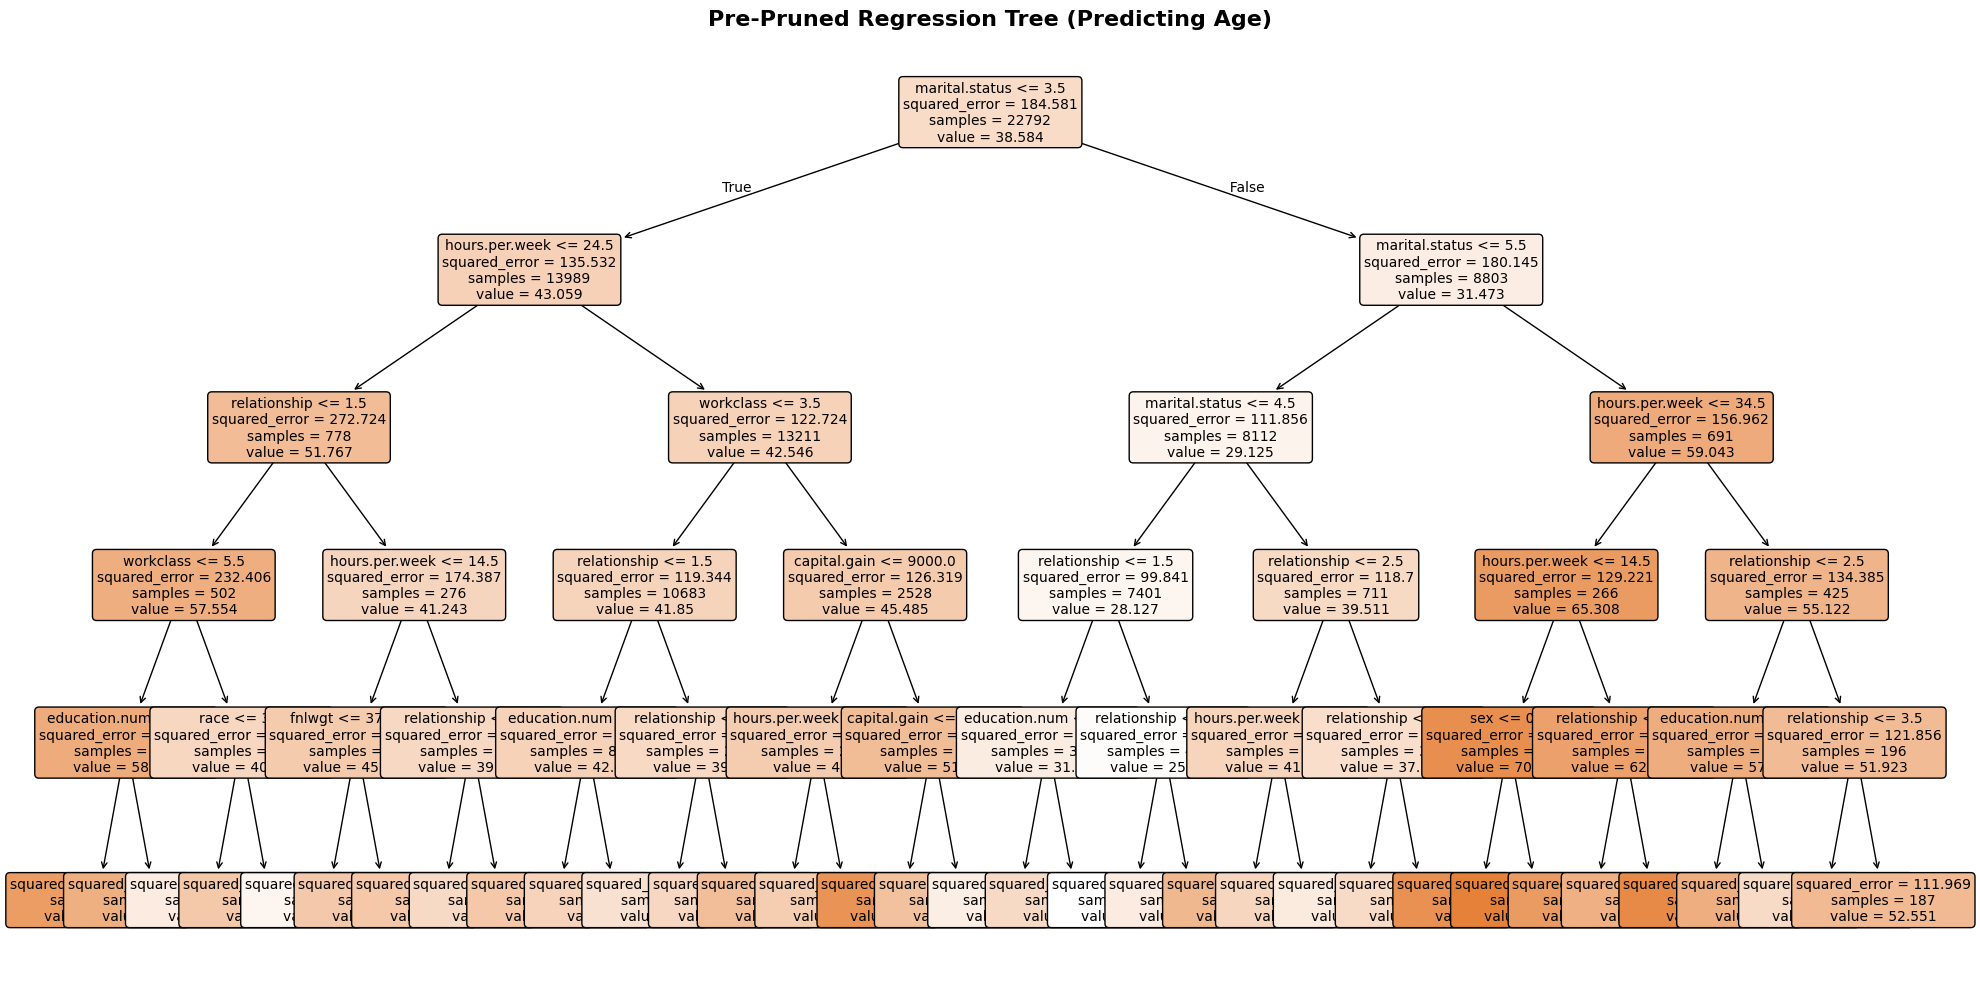

In [16]:
# Visualization of Pre-Pruned Regression Tree
plt.figure(figsize=(20, 10))
plot_tree(
    dt_reg_pruned,
    feature_names=X_reg.columns,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Pre-Pruned Regression Tree (Predicting Age)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.6 Regression Tree Visualization

Visualize the **pre-pruned regression tree** structure:

**How to Read the Regression Tree:**
- **Root Node**: First split criterion (feature and threshold)
- **Internal Nodes**: Show:
  - Feature name and split value
  - MSE value (mean squared error at that node)
  - Number of samples
  - Mean value of samples in node
- **Leaf Nodes**: Show predicted age value (mean of samples in leaf)
- **Colors**: Gradient from blue (low values) to orange (high values)

**Interpretation:**
- Each leaf node predicts a single continuous value
- More leaves = more specific predictions
- Simpler structure = easier to understand decision rules


FEATURE IMPORTANCE (Regression Tree)
marital.status    0.788626
relationship      0.111831
hours.per.week    0.052732
education.num     0.019908
workclass         0.019729
capital.gain      0.005614
race              0.000702
fnlwgt            0.000546
sex               0.000312
education         0.000000
occupation        0.000000
capital.loss      0.000000
native.country    0.000000
dtype: float64



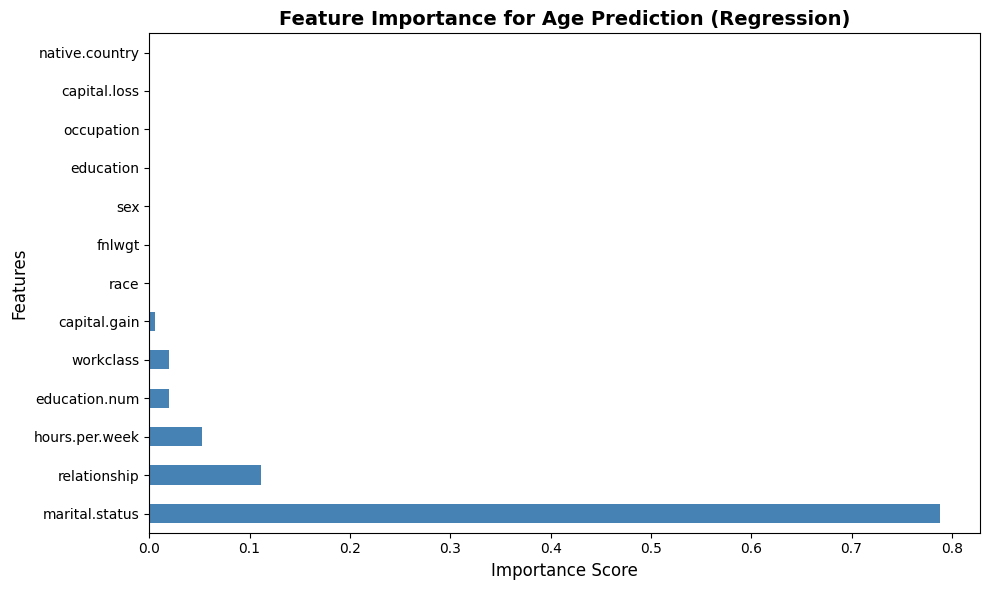

In [17]:
# Feature Importance for Regression Tree
reg_importances = pd.Series(
    dt_reg_pruned.feature_importances_,
    index=X_reg.columns
).sort_values(ascending=False)

print("=" * 50)
print("FEATURE IMPORTANCE (Regression Tree)")
print("=" * 50)
print(reg_importances)
print()

# Visualize Feature Importance
plt.figure(figsize=(10, 6))
reg_importances.plot(kind='barh', color='steelblue')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Feature Importance for Age Prediction (Regression)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.7 Regression Tree Feature Importance Analysis

Identify which features are most influential for predicting age:

**Key Points:**
- Same importance calculation as classification
- Ranks features by contribution to MSE reduction
- Features with zero importance: Not used in any splits
- Useful for feature selection and data quality assessment

**Visualization:**
- Horizontal bar chart shows relative importance
- Sorted in descending order
- Helps identify:
  - Critical predictive features
  - Redundant features that could be removed
  - Data collection priorities

---

## 8. Comparative Analysis and Conclusions

### 8.1 Classification vs Regression Results Comparison

Let's create a comprehensive comparison of all models:


In [18]:
# Summary Comparison of All Models
print("\n" + "=" * 70)
print("COMPREHENSIVE MODEL COMPARISON".center(70))
print("=" * 70)

print("\n" + "-" * 70)
print("CLASSIFICATION MODELS (Predicting Income: <=50K or >50K)")
print("-" * 70)

print(f"\n1. Full Tree (Entropy):")
print(f"   Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print(f"\n2. Full Tree (Gini):")
print(f"   Accuracy: {accuracy_score(y_test, y_pred_gini):.4f}")

print(f"\n3. Pre-Pruned Tree (Entropy, max_depth=3):")
print(f"   Accuracy: {accuracy_score(y_test, y_pred_pruned):.4f}")

print(f"\n4. Post-Pruned Tree (Entropy, CCP):")
print(f"   Accuracy: {accuracy_score(y_test, y_pred_post):.4f}")

print("\n" + "-" * 70)
print("REGRESSION MODELS (Predicting Age)")
print("-" * 70)

print(f"\n1. Full Regression Tree (MSE):")
print(f"   MSE: {mse_full:.4f} | RMSE: {rmse_full:.4f} | MAE: {mae_full:.4f} | R²: {r2_full:.4f}")

print(f"\n2. Pre-Pruned Regression Tree (max_depth=5):")
print(f"   MSE: {mse_pruned:.4f} | RMSE: {rmse_pruned:.4f} | MAE: {mae_pruned:.4f} | R²: {r2_pruned:.4f}")

print(f"\n3. Post-Pruned Regression Tree (CCP):")
print(f"   MSE: {mse_post:.4f} | RMSE: {rmse_post:.4f} | MAE: {mae_post:.4f} | R²: {r2_post:.4f}")

print("\n" + "=" * 70)
print("KEY INSIGHTS")
print("=" * 70)

# Classification insights
best_class_acc = max(
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, y_pred_gini),
    accuracy_score(y_test, y_pred_pruned),
    accuracy_score(y_test, y_pred_post)
)

print(f"\nCLASSIFICATION:")
print(f"  • Best Accuracy: {best_class_acc:.4f}")
print(f"  • Entropy vs Gini: Similar performance (validates both criteria)")
print(f"  • Pruning Impact: Compare full vs pruned accuracies")
if accuracy_score(y_test, y_pred_pruned) > accuracy_score(y_test, y_pred):
    print(f"    → Pruning IMPROVED accuracy (original tree was overfitting)")
else:
    print(f"    → Pruning DECREASED accuracy (original tree was appropriate)")

print(f"\nREGRESSION:")
print(f"  • Best R² Score: {max(r2_full, r2_pruned, r2_post):.4f}")
print(f"  • Average Prediction Error (MAE): {mae_pruned:.4f} years")
print(f"  • Pre-pruning vs Full Tree:")
if rmse_pruned < rmse_full:
    print(f"    → Pre-pruned generalizes better (less overfitting)")
else:
    print(f"    → Full tree performs better (less underfitting)")

print("\n" + "=" * 70)


                    COMPREHENSIVE MODEL COMPARISON                    

----------------------------------------------------------------------
CLASSIFICATION MODELS (Predicting Income: <=50K or >50K)
----------------------------------------------------------------------

1. Full Tree (Entropy):
   Accuracy: 0.8190

2. Full Tree (Gini):
   Accuracy: 0.8157

3. Pre-Pruned Tree (Entropy, max_depth=3):
   Accuracy: 0.8389

4. Post-Pruned Tree (Entropy, CCP):
   Accuracy: 0.8589

----------------------------------------------------------------------
REGRESSION MODELS (Predicting Age)
----------------------------------------------------------------------

1. Full Regression Tree (MSE):
   MSE: 202.3656 | RMSE: 14.2255 | MAE: 10.6351 | R²: -0.0679

2. Pre-Pruned Regression Tree (max_depth=5):
   MSE: 112.1806 | RMSE: 10.5915 | MAE: 8.2278 | R²: 0.4080

3. Post-Pruned Regression Tree (CCP):
   MSE: 168.9479 | RMSE: 12.9980 | MAE: 9.5261 | R²: 0.1084

KEY INSIGHTS

CLASSIFICATION:
  • Best Acc

### 8.2 Model Comparison Summary

This comprehensive comparison evaluates:

**Classification Performance:**
- Entropy vs Gini: Validates that both splitting criteria produce similar results
- Full vs Pruned: Demonstrates overfitting detection and prevention
- Post-pruning effectiveness: Shows optimal balance between accuracy and complexity

**Regression Performance:**
- Model complexity: Compares full vs pruned tree structures
- Generalization: Evaluates MSE, RMSE, MAE, and R² metrics
- Robustness: Checks consistency across different pruning strategies

**Key Findings:**
1. Which model achieves best accuracy?
2. Does pruning improve generalization?
3. Which features are most important for each task?
4. Can same dataset work for both classification and regression?

---

## 9. Project Summary and Takeaways

### 9.1 What We Learned

**Decision Tree Fundamentals:**
✓ Decision trees are intuitive, interpretable models for classification and regression
✓ Entropy and Gini index are equivalent splitting criteria with minimal performance differences
✓ Pre-pruning and post-pruning both effectively prevent overfitting

**Practical Implementation:**
✓ Scikit-learn provides robust implementations of decision trees
✓ Proper train-test split prevents overfitting detection bias
✓ Feature importance helps identify critical predictive variables

**Model Optimization:**
✓ Pruning is essential for production models
✓ Post-pruning generally outperforms pre-pruning
✓ Evaluation metrics must match task type (accuracy for classification, MSE/R² for regression)

